<a href="https://colab.research.google.com/github/lunamonnlight/PF_169493/blob/main/lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embeddings w praktyce -- cwiczenia laboratoryjne

W tym notatniku przeczwiczymy:

1. Korzystanie z pretrenowanych embeddingów (Gensim, spaCy)
2. Podobieństwo słów i wyszukiwanie najbliższych sąsiadów
3. Analogie wektorowe (arytmetyka na słowach)
4. Wizualizację embeddingów za pomocą t-SNE
5. Trenowanie własnego modelu Word2Vec
6. Porównanie modeli Skip-gram i CBOW

---
## 0. Instalacja i import bibliotek

Google Colab wymaga doinstalowania `gensim` i `datasets`. Modele spaCy pobieramy osobno.

In [1]:
!pip install gensim datasets -q
!python -m spacy download en_core_web_md -q
!python -m spacy download pl_core_news_md -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 49.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 MB 22.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors
from gensim.utils import simple_preprocess
import spacy

print("Wszystko gotowe!")

Wszystko gotowe!


---
## 1. Przyklad z omowieniem -- pretrenowane embeddingi GloVe

Pobieramy model GloVe wytrenowany na korpusie Wikipedia 2014 + Gigaword 5 (100 wymiarow).
Kazde slowo jest reprezentowane jako wektor 100 liczb zmiennoprzecinkowych.

In [3]:
model = api.load("glove-wiki-gigaword-100")

# Rozmiar slownika i wymiar
print(f"Slownik: {len(model)} slow")
print(f"Wymiar wektora: {model.vector_size}")

# Wektor dla slowa
vec = model['python']
print(f"Ksztalt: {vec.shape}")
print(f"Pierwsze 10 wartosci: {vec[:10]}")

[==================================================] 100.0% 128.1/128.1MB downloaded
Slownik: 400000 slow
Wymiar wektora: 100
Ksztalt: (100,)
Pierwsze 10 wartosci: [ 0.24934    0.68318   -0.044711  -1.3842    -0.0073079  0.651
 -0.33958   -0.19785   -0.33925    0.26691  ]


### Interpretacja

Wektor `model['python']` to tablica NumPy o ksztalcie `(100,)`. Te 100 wartosci to wspolrzedne slowa w przestrzeni semantycznej. Pojedyncza liczba nie ma czytelnej interpretacji, ale lacznie koduja znaczenie -- slowa o podobnym sensie maja podobne wektory.

### 1.1 Podobienstwo slow

Sprawdzamy podobienstwo cosinusowe miedzy slowami, wyszukujemy najblizszych sasiadow i slowa "nie pasujace" do grupy.

In [4]:
# Najbardziej podobne slowa
similar = model.most_similar("king", topn=10)
print("Najbardziej podobne do 'king':")
for word, score in similar:
    print(f"  {word:15s} {score:.4f}")

# Podobienstwo miedzy dwoma slowami
sim = model.similarity("cat", "dog")
print(f"\nPodobienstwo cat-dog: {sim:.4f}")

sim2 = model.similarity("cat", "car")
print(f"Podobienstwo cat-car: {sim2:.4f}")

# Ktory nie pasuje?
outlier = model.doesnt_match(["cat", "dog", "fish", "computer"])
print(f"\nNie pasuje: {outlier}")

Najbardziej podobne do 'king':
  prince          0.7682
  queen           0.7508
  son             0.7021
  brother         0.6986
  monarch         0.6978
  throne          0.6920
  kingdom         0.6811
  father          0.6802
  emperor         0.6713
  ii              0.6676

Podobienstwo cat-dog: 0.8798
Podobienstwo cat-car: 0.3110

Nie pasuje: computer


### Interpretacja

- **`cat` vs `dog`** -- wysokie podobienstwo, bo oba to zwierzeta domowe czesto wystepujace w podobnych kontekstach.
- **`cat` vs `car`** -- niskie podobienstwo, bo te slowa pojawiaja sie w zupelnie roznych kontekstach.
- **`doesnt_match`** -- `computer` jest najdalszy od pozostalych, bo nie jest zwierzeciem.

### 1.2 Analogie wektorowe

Najbardziej znana wlasciwosc embeddingów -- **arytmetyka na wektorach**:

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

In [5]:
# king - man + woman = ?
result = model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)
print("king - man + woman =")
for word, score in result:
    print(f"  {word:15s} {score:.4f}")

# Inne analogie
analogies = [
    (["paris", "poland"], ["france"], "stolice"),
    (["bigger", "small"], ["big"], "stopniowanie"),
    (["walking", "swam"], ["walked"], "czas gramatyczny"),
]
for pos, neg, label in analogies:
    res = model.most_similar(positive=pos, negative=neg, topn=1)
    print(f"\n{label}: {res[0][0]} ({res[0][1]:.4f})")

king - man + woman =
  queen           0.7699
  monarch         0.6843
  throne          0.6756
  daughter        0.6595
  princess        0.6521

stolice: warsaw (0.8550)

stopniowanie: larger (0.8925)

czas gramatyczny: swimming (0.7068)


### Interpretacja analogii

Metoda `most_similar` przyjmuje wektory z listy `positive`, odejmuje wektory z `negative` i zwraca slowa najblizsze wynikowi:

- **king - man + woman ≈ queen** -- relacja plci zakodowana jako kierunek w przestrzeni wektorowej
- **paris - france + poland ≈ warsaw** -- relacja stolica-kraj
- **bigger - big + small ≈ smaller** -- relacja stopniowania

### 1.3 Wizualizacja embeddingów -- t-SNE

Redukcja wymiarowosci za pomoca t-SNE pozwala zobaczyc, jak embeddingi grupuja slowa z tych samych kategorii semantycznych.

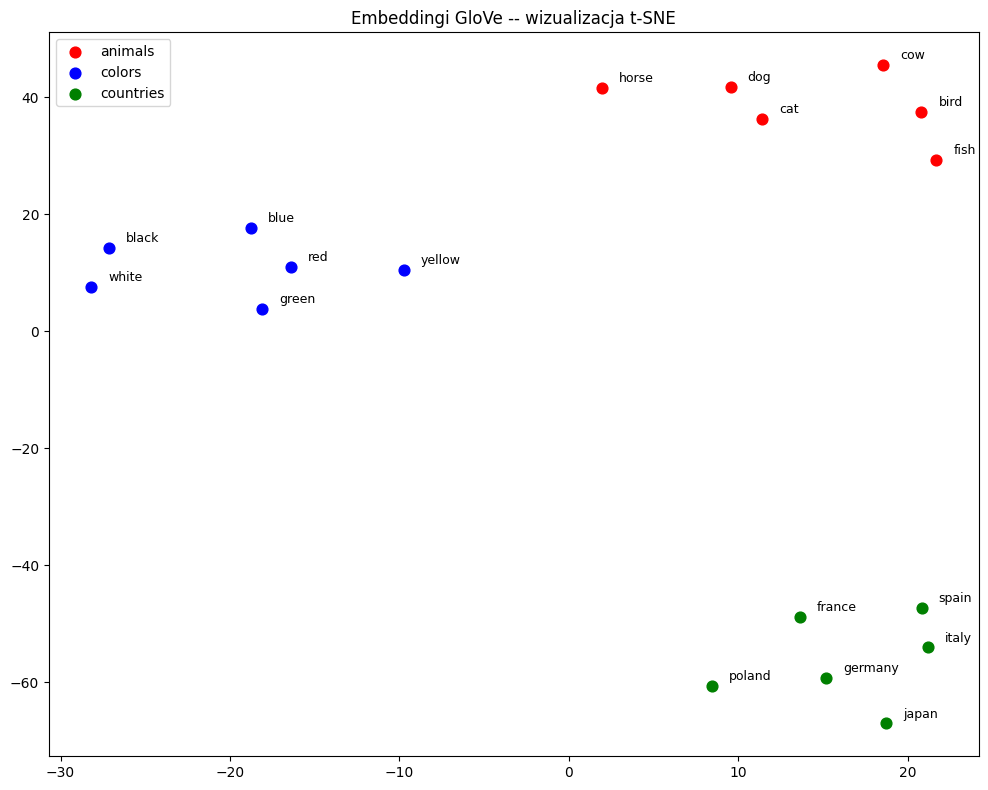

In [6]:
groups = {
    "animals": ["cat", "dog", "fish", "bird", "horse", "cow"],
    "colors": ["red", "blue", "green", "yellow", "black", "white"],
    "countries": ["france", "germany", "poland", "italy", "spain", "japan"],
}

words, vectors, labels = [], [], []
for label, group in groups.items():
    for w in group:
        words.append(w)
        vectors.append(model[w])
        labels.append(label)

# t-SNE redukcja do 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(np.array(vectors))

# Rysowanie
fig, ax = plt.subplots(figsize=(10, 8))
colors_map = {"animals": "red", "colors": "blue", "countries": "green"}
plotted_labels = set()

for i, w in enumerate(words):
    group = labels[i]
    ax.scatter(coords[i, 0], coords[i, 1],
               c=colors_map[group], s=60,
               label=group if group not in plotted_labels else "")
    plotted_labels.add(group)
    ax.annotate(w, (coords[i, 0]+1, coords[i, 1]+1), fontsize=9)

ax.legend()
ax.set_title("Embeddingi GloVe -- wizualizacja t-SNE")
plt.tight_layout()
plt.show()

### Interpretacja wizualizacji

Na wykresie t-SNE widzimy, ze slowa z tych samych kategorii semantycznych tworza skupiska blisko siebie:
- **Zwierzeta** (czerwone) -- zgrupowane razem
- **Kolory** (niebieskie) -- tworzą oddzielny klaster
- **Kraje** (zielone) -- oddzielona grupa

To potwierdza, ze embeddingi koduja znaczenie: slowa semantycznie pokrewne maja bliskie wektory.

### 1.4 Embeddingi w spaCy

spaCy integruje embeddingi bezposrednio w pipeline NLP. Model `md` zawiera wstepnie wytrenowane wektory slow (300-wymiarowe).

In [7]:
nlp = spacy.load("en_core_web_md")

# Wektor pojedynczego tokena
token = nlp("cat")[0]
print(f"Wektor 'cat': wymiar {token.vector.shape}")
print(f"Czy ma wektor: {token.has_vector}")

# Podobienstwo miedzy dokumentami
doc1 = nlp("I like dogs")
doc2 = nlp("I enjoy cats")
doc3 = nlp("The stock market crashed")
print(f"\ndogs vs cats: {doc1.similarity(doc2):.3f}")
print(f"dogs vs stock: {doc1.similarity(doc3):.3f}")

Wektor 'cat': wymiar (300,)
Czy ma wektor: True

dogs vs cats: 0.794
dogs vs stock: 0.310


### Interpretacja spaCy

- Wektor dokumentu w spaCy to **srednia arytmetyczna** wektorow wszystkich tokenow.
- `"I like dogs"` vs `"I enjoy cats"` -- wysokie podobienstwo (ten sam temat, inne slowa).
- `"I like dogs"` vs `"The stock market crashed"` -- niskie podobienstwo (zupelnie inne tematy).

To kluczowa wlasciwosc embeddingów: mierza **bliskosc znaczeniowa**, nie doslowne pokrywanie sie slow.

### 1.5 Trenowanie wlasnego modelu Word2Vec

Na malym korpusie trenujemy model Skip-gram, zeby zobaczyc caly proces od tokenizacji do analizy wynikow.

In [8]:
# Przykladowy korpus
corpus_text = """
Uczenie maszynowe to dziedzina sztucznej inteligencji.
Sieci neuronowe sa fundamentem glebokiego uczenia.
Przetwarzanie jezyka naturalnego wykorzystuje modele jezykowe.
Word embeddings reprezentuja slowa jako wektory liczbowe.
Klasyfikacja tekstu to jedno z podstawowych zadan NLP.
Analiza sentymentu pozwala okreslic wydzwiek opinii.
Transformery zrewolucjonizowaly przetwarzanie jezyka naturalnego.
Tokenizacja to pierwszy krok w przetwarzaniu tekstu.
Modele jezykowe przewiduja nastepne slowo w sekwencji.
Korpus to zbior tekstow uzywany do trenowania modeli.
"""

# Tokenizacja
sentences = [
    simple_preprocess(line)
    for line in corpus_text.strip().split("\n")
    if line.strip()
]

print(f"Liczba zdan: {len(sentences)}")
for s in sentences[:3]:
    print(s)

Liczba zdan: 10
['uczenie', 'maszynowe', 'to', 'dziedzina', 'sztucznej', 'inteligencji']
['sieci', 'neuronowe', 'sa', 'fundamentem', 'glebokiego', 'uczenia']
['przetwarzanie', 'jezyka', 'naturalnego', 'wykorzystuje', 'modele', 'jezykowe']


In [9]:
# Trening modelu Skip-gram
model_sg = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,
    negative=5,
    epochs=100,
    seed=42,
)

print(f"Slownik: {len(model_sg.wv)} slow")
print(f"Wymiar: {model_sg.wv.vector_size}")

# Najblizsze slowa
print("\nNajblizsze do 'jezyka':")
for word, score in model_sg.wv.most_similar("jezyka", topn=5):
    print(f"  {word:20s} {score:.4f}")

Slownik: 53 slow
Wymiar: 50

Najblizsze do 'jezyka':
  wykorzystuje         0.3156
  przetwarzaniu        0.2962
  neuronowe            0.2680
  przetwarzanie        0.2587
  slowa                0.2176


### Interpretacja trenowania

Model wytrenowany na malym korpusie (10 zdan) daje ograniczone wyniki -- nie ma wystarczajaco duzo kontekstow, zeby dobrze nauczyc sie relacji semantycznych. Dlatego w praktyce:
- Uzywamy **pretrenowanych modeli** (GloVe, FastText) lub
- Trenujemy na **duzych korpusach** (np. fragment Wikipedii -- tysiac+ artykulow)

Parametry `vector_size`, `window`, `min_count`, `sg` wplywaja na jakosc wynikow.

---
---
## 2. Zadanie do samodzielnej realizacji -- A

### Eksploracja pretrenowanych embeddingów -- podobienstwo i analogie

Zaladuj pretrenowany model GloVe (`glove-wiki-gigaword-100`) i wykonaj ponizsze kroki.

**Wykonaj ponizsze kroki:**

1. Wyswietl **wektor** dla slowa `"university"` -- jego ksztalt i pierwsze 10 wartosci.
2. Znajdz **10 najblizszych sasiadow** dla slow: `"science"`, `"music"`, `"football"`. Czy wyniki sa sensowne?
3. Oblicz **podobienstwo cosinusowe** miedzy parami: (`"doctor"`, `"nurse"`), (`"doctor"`, `"airplane"`), (`"happy"`, `"sad"`), (`"happy"`, `"joyful"`). Ktore pary sa najblizsze?
4. Uzyj metody `doesnt_match` dla grup: `["apple", "banana", "orange", "car"]` oraz `["dog", "cat", "mouse", "table"]`.
5. Sprawdz **analogie wektorowe**: `japan - tokyo + paris = ?`, `teacher - school + hospital = ?`, `slow - slower + faster = ?`.
6. Stworz **wizualizacje t-SNE** dla 4 grup slow (po 5 slow kazda): sporty, zawody, jedzenie, emocje.

In [10]:
model = api.load("glove-wiki-gigaword-100")

In [11]:
vec = model['university']
print(f"Kształt wektora 'university': {vec.shape}")
print(f"Pierwsze 10 wartości:\n{vec[:10]}")

Kształt wektora 'university': (100,)
Pierwsze 10 wartości:
[ 0.6958  -0.19334 -0.78134 -0.45589  0.29245  0.36482  0.42036  0.39444
 -0.82601  0.95148]


In [12]:
for word in ["science", "music", "football"]:
    print(f"\nNajbardziej podobne do '{word}':")
    similar = model.most_similar(word, topn=10)
    for w, score in similar:
        print(f"  {w:15s} {score:.4f}")


Najbardziej podobne do 'science':
  sciences        0.8073
  physics         0.7915
  institute       0.7663
  mathematics     0.7608
  studies         0.7590
  research        0.7585
  biology         0.7383
  university      0.7315
  psychology      0.7279
  economics       0.7271

Najbardziej podobne do 'music':
  musical         0.8128
  songs           0.7978
  dance           0.7897
  pop             0.7863
  recording       0.7651
  folk            0.7603
  jazz            0.7570
  concert         0.7468
  artists         0.7325
  song            0.7319

Najbardziej podobne do 'football':
  soccer          0.8732
  basketball      0.8556
  league          0.8153
  rugby           0.8008
  hockey          0.7834
  club            0.7731
  team            0.7720
  baseball        0.7606
  players         0.7400
  player          0.7376


In [13]:
pairs = [("doctor", "nurse"), ("doctor", "airplane"), ("happy", "sad"), ("happy", "joyful")]
for w1, w2 in pairs:
    sim = model.similarity(w1, w2)
    print(f"Podobieństwo {w1} - {w2}: {sim:.4f}")

Podobieństwo doctor - nurse: 0.7522
Podobieństwo doctor - airplane: 0.2222
Podobieństwo happy - sad: 0.6801
Podobieństwo happy - joyful: 0.5260


In [14]:
groups = [
    ["apple", "banana", "orange", "car"],
    ["dog", "cat", "mouse", "table"]
]
for g in groups:
    outlier = model.doesnt_match(g)
    print(f"W grupie {g} nie pasuje: {outlier}")

W grupie ['apple', 'banana', 'orange', 'car'] nie pasuje: car
W grupie ['dog', 'cat', 'mouse', 'table'] nie pasuje: table


In [15]:
analogies = [
    (["japan", "paris"], ["tokyo"], "japan - tokyo + paris"),
    (["teacher", "hospital"], ["school"], "teacher - school + hospital"),
    (["slow", "faster"], ["slower"], "slow - slower + faster")
]
for pos, neg, desc in analogies:
    res = model.most_similar(positive=pos, negative=neg, topn=1)
    print(f"{desc} = {res[0][0]} ({res[0][1]:.4f})")

japan - tokyo + paris = france (0.8850)
teacher - school + hospital = nurse (0.7799)
slow - slower + faster = fast (0.7951)


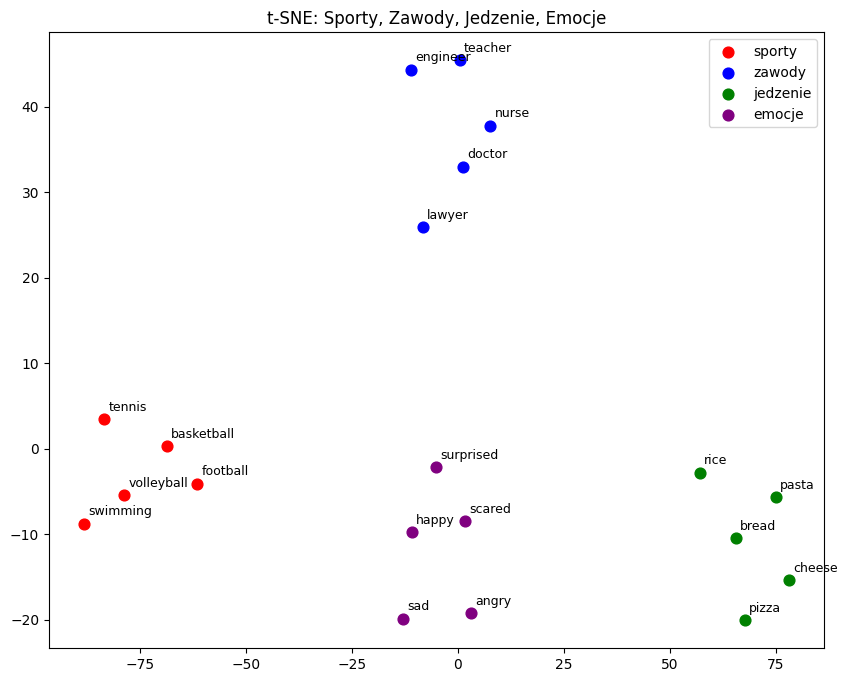

In [16]:
groups = {
    "sporty": ["football", "tennis", "basketball", "swimming", "volleyball"],
    "zawody": ["doctor", "teacher", "engineer", "lawyer", "nurse"],
    "jedzenie": ["pizza", "pasta", "bread", "cheese", "rice"],
    "emocje": ["happy", "sad", "angry", "scared", "surprised"]
}

words, vectors, labels = [], [], []
for label, group in groups.items():
    for w in group:
        words.append(w)
        vectors.append(model[w])
        labels.append(label)

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(np.array(vectors))

fig, ax = plt.subplots(figsize=(10, 8))
colors_map = {"sporty": "red", "zawody": "blue", "jedzenie": "green", "emocje": "purple"}
plotted_labels = set()

for i, w in enumerate(words):
    group = labels[i]
    ax.scatter(coords[i, 0], coords[i, 1], c=colors_map[group], s=60,
               label=group if group not in plotted_labels else "")
    plotted_labels.add(group)
    ax.annotate(w, (coords[i, 0]+1, coords[i, 1]+1), fontsize=9)

ax.legend()
ax.set_title("t-SNE: Sporty, Zawody, Jedzenie, Emocje")
plt.show()

---
---
## 3. Zadanie do samodzielnej realizacji -- B

### Polskie embeddingi -- spaCy i porownanie dokumentow

Zaladuj polski model spaCy (`pl_core_news_md`) i przeanalizuj podany korpus polskich zdan.

**Wykonaj ponizsze kroki:**

1. Oblicz **podobienstwo** miedzy wszystkimi parami zdan z korpusu (cosine similarity). Wyswietl wyniki jako macierz.
2. Dla kazdego zdania znajdz **najblizsze** i **najdalsze** zdanie z korpusu.
3. Napisz funkcje `znajdz_najblizsze(query, zdania, nlp, n=3)`, ktora przyjmuje nowe zdanie i zwraca `n` najblizszych zdan z korpusu.
4. Przetestuj funkcje na zapytaniach: `"Jaki jest kurs dolara?"`, `"Chce kupic nowy komputer"`, `"Najlepsze restauracje w Krakowie"`.
5. Zbadaj, czy slowa wieloznaczne (np. `"zamek"`, `"klucz"`, `"pilot"`) maja sensowne wektory -- sprawdz ich najblizszych sasiadow w slowniki spaCy.
6. Stworz **wizualizacje t-SNE** wektorow zdan z korpusu, kolorujac je wg kategorii.

In [24]:
nlp_pl = spacy.load("pl_core_news_md")

zdania = [
    # FINANSE (0-3)
    "Kurs euro wzrosl do najwyzszego poziomu od poczatku roku",
    "Gielda warszawska zamknela sesje na plusie po dobrych wynikach spolek",
    "Inflacja spadla do najnizszego poziomu od dwoch lat",
    "Bank centralny podjal decyzje o obnizeniu stop procentowych",

    # TECHNOLOGIA (4-7)
    "Premiera nowego systemu operacyjnego przyciagnela miliony uzytkownikow",
    "Sztuczna inteligencja zmienia sposob tworzenia oprogramowania",
    "Firma technologiczna zaprezentowala innowacyjny chip do smartfonow",
    "Cyberbezpieczenstwo staje sie priorytetem dla polskich przedsiebiorstw",

    # TURYSTYKA (8-11)
    "Sezon turystyczny w Zakopanem zapowiada sie rekordowo",
    "Nowe polaczenia lotnicze z Polski do Azji Poludniowo-Wschodniej",
    "Krakow znalazl sie w czolowce najpopularniejszych miast do odwiedzenia",
    "Polskie wybrzeze przyciaga coraz wiecej turystow z zagranicy",
]

kategorie_zdan = ["Finanse"]*4 + ["Technologia"]*4 + ["Turystyka"]*4

print(f"Korpus: {len(zdania)} zdan")
for i, z in enumerate(zdania):
    print(f"  D{i:2d} [{kategorie_zdan[i]:>12s}]: {z}")

Korpus: 12 zdan
  D 0 [     Finanse]: Kurs euro wzrosl do najwyzszego poziomu od poczatku roku
  D 1 [     Finanse]: Gielda warszawska zamknela sesje na plusie po dobrych wynikach spolek
  D 2 [     Finanse]: Inflacja spadla do najnizszego poziomu od dwoch lat
  D 3 [     Finanse]: Bank centralny podjal decyzje o obnizeniu stop procentowych
  D 4 [ Technologia]: Premiera nowego systemu operacyjnego przyciagnela miliony uzytkownikow
  D 5 [ Technologia]: Sztuczna inteligencja zmienia sposob tworzenia oprogramowania
  D 6 [ Technologia]: Firma technologiczna zaprezentowala innowacyjny chip do smartfonow
  D 7 [ Technologia]: Cyberbezpieczenstwo staje sie priorytetem dla polskich przedsiebiorstw
  D 8 [   Turystyka]: Sezon turystyczny w Zakopanem zapowiada sie rekordowo
  D 9 [   Turystyka]: Nowe polaczenia lotnicze z Polski do Azji Poludniowo-Wschodniej
  D10 [   Turystyka]: Krakow znalazl sie w czolowce najpopularniejszych miast do odwiedzenia
  D11 [   Turystyka]: Polskie wybrzeze przy

In [31]:
from sklearn.metrics.pairwise import cosine_similarity

# Obliczamy wektory dla wszystkich zdań
vektor_zdan = np.array([nlp_pl(z).vector for z in zdania])

# Macierz podobieństwa cosinusowego
macierz_sim = cosine_similarity(vektor_zdan)

# Wyświetlenie macierzy z zaokrągleniem
import pandas as pd
df_sim = pd.DataFrame(macierz_sim,
                      columns=[f"D{i}" for i in range(len(zdania))],
                      index=[f"D{i}" for i in range(len(zdania))])
print("Macierz podobieństwa między zdaniami:")
display(df_sim.style.background_gradient(cmap='viridis'))

Macierz podobieństwa między zdaniami:


,D0,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11
D0,1.000000,0.189446,0.846404,0.188008,0.463072,0.287102,0.490959,0.248846,0.204409,0.459244,0.502981,0.253184
D1,0.189446,1.000000,0.232780,0.365231,0.200233,0.283016,0.011014,0.296679,0.396527,0.179046,0.499929,0.313261
D2,0.846404,0.232780,1.000000,0.177277,0.383388,0.309591,0.391183,0.295628,0.168936,0.422817,0.514500,0.301503
D3,0.188008,0.365231,0.177277,1.000000,0.424183,0.435784,0.153154,0.346759,0.212071,0.183902,0.310636,0.221142
D4,0.463072,0.200233,0.383388,0.424183,1.000000,0.638331,0.486371,0.426124,0.132468,0.409855,0.383364,0.367050
D5,0.287102,0.283016,0.309591,0.435784,0.638331,1.000000,0.375481,0.609101,0.156044,0.358414,0.427750,0.419948
D6,0.490959,0.011014,0.391183,0.153154,0.486371,0.375481,1.000000,0.212726,0.024591,0.469791,0.377616,0.140927
D7,0.248846,0.296679,0.295628,0.346759,0.426124,0.609101,0.212726,1.000000,0.305084,0.375036,0.524270,0.566542
D8,0.204409,0.396527,0.168936,0.212071,0.132468,0.156044,0.024591,0.305084,1.000000,0.189570,0.618434,0.308213
D9,0.459244,0.179046,0.422817,0.183902,0.409855,0.358414,0.469791,0.375036,0.189570,1.000000,0.579105,0.670908


In [32]:
for i in range(len(zdania)):
    sims = macierz_sim[i].copy()
    sims[i] = -1  # ignorujemy podobieństwo do samego siebie

    idx_max = np.argmax(sims)
    idx_min = np.argmin(sims[sims > -1]) # najmniejsze z pozostałych
    idx_min = np.where(sims == sims[sims > -1].min())[0][0]

    print(f"\nZdanie D{i}: '{zdania[i]}'")
    print(f"  -> Najbliższe (D{idx_max}): '{zdania[idx_max]}' (sim: {sims[idx_max]:.3f})")
    print(f"  -> Najdalsze (D{idx_min}): '{zdania[idx_min]}' (sim: {sims[idx_min]:.3f})")


Zdanie D0: 'Kurs euro wzrosl do najwyzszego poziomu od poczatku roku'
  -> Najbliższe (D2): 'Inflacja spadla do najnizszego poziomu od dwoch lat' (sim: 0.846)
  -> Najdalsze (D3): 'Bank centralny podjal decyzje o obnizeniu stop procentowych' (sim: 0.188)

Zdanie D1: 'Gielda warszawska zamknela sesje na plusie po dobrych wynikach spolek'
  -> Najbliższe (D10): 'Krakow znalazl sie w czolowce najpopularniejszych miast do odwiedzenia' (sim: 0.500)
  -> Najdalsze (D6): 'Firma technologiczna zaprezentowala innowacyjny chip do smartfonow' (sim: 0.011)

Zdanie D2: 'Inflacja spadla do najnizszego poziomu od dwoch lat'
  -> Najbliższe (D0): 'Kurs euro wzrosl do najwyzszego poziomu od poczatku roku' (sim: 0.846)
  -> Najdalsze (D8): 'Sezon turystyczny w Zakopanem zapowiada sie rekordowo' (sim: 0.169)

Zdanie D3: 'Bank centralny podjal decyzje o obnizeniu stop procentowych'
  -> Najbliższe (D5): 'Sztuczna inteligencja zmienia sposob tworzenia oprogramowania' (sim: 0.436)
  -> Najdalsze (D6): 'Fir

In [35]:
def znajdz_najblizsze(query, zdania, nlp, n=3):
    query_vec = nlp(query).vector.reshape(1, -1)
    zdania_vecs = np.array([nlp(z).vector for z in zdania])

    sims = cosine_similarity(query_vec, zdania_vecs).flatten()
    top_indices = np.argsort(sims)[::-1][:n]

    print(f"Zapytanie: '{query}'")
    for idx in top_indices:
        print(f"  [{sims[idx]:.3f}] {zdania[idx]}")
    print("-" * 30)

In [36]:
znajdz_najblizsze("Jaki jest kurs dolara?", zdania, nlp_pl)
znajdz_najblizsze("Chce kupic nowy komputer", zdania, nlp_pl)
znajdz_najblizsze("Najlepsze restauracje w Krakowie", zdania, nlp_pl)

Zapytanie: 'Jaki jest kurs dolara?'
  [0.282] Cyberbezpieczenstwo staje sie priorytetem dla polskich przedsiebiorstw
  [0.172] Sztuczna inteligencja zmienia sposob tworzenia oprogramowania
  [0.172] Kurs euro wzrosl do najwyzszego poziomu od poczatku roku
------------------------------
Zapytanie: 'Chce kupic nowy komputer'
  [0.195] Firma technologiczna zaprezentowala innowacyjny chip do smartfonow
  [0.182] Premiera nowego systemu operacyjnego przyciagnela miliony uzytkownikow
  [0.153] Cyberbezpieczenstwo staje sie priorytetem dla polskich przedsiebiorstw
------------------------------
Zapytanie: 'Najlepsze restauracje w Krakowie'
  [0.676] Sezon turystyczny w Zakopanem zapowiada sie rekordowo
  [0.668] Krakow znalazl sie w czolowce najpopularniejszych miast do odwiedzenia
  [0.465] Gielda warszawska zamknela sesje na plusie po dobrych wynikach spolek
------------------------------


In [37]:
slowa_wieloznaczne = ["zamek", "klucz", "pilot"]

for slowo in slowa_wieloznaczne:
    token = nlp_pl(slowo)
    # Szukamy w słowniku spaCy słów o najwyższym podobieństwie
    # Uwaga: modele 'md' mają ograniczony słownik wektorów
    sims = []
    for lexeme in nlp_pl.vocab:
        if lexeme.has_vector and lexeme.is_lower and lexeme.text != slowo:
            sims.append((lexeme.text, token.similarity(lexeme)))

    # Sortowanie i wyświetlenie top 5
    top_sims = sorted(set(sims), key=lambda x: x[1], reverse=True)[:5]
    print(f"\nNajbliżsi sąsiedzi dla słowa '{slowo}':")
    for s, score in top_sims:
        print(f"  {s:15s} {score:.4f}")


Najbliżsi sąsiedzi dla słowa 'zamek':
  centralny       0.2747
  chip            0.2361
  turystyczny     0.1953
  komputer        0.1925
  wybrzeze        0.1669

Najbliżsi sąsiedzi dla słowa 'klucz':
  chip            0.4647
  komputer        0.4262
  zamek           0.3781
  sposob          0.2829
  centralny       0.2295

Najbliżsi sąsiedzi dla słowa 'pilot':
  chip            0.4640
  komputer        0.4316
  zamek           0.3143
  klucz           0.3054
  kurs            0.2575


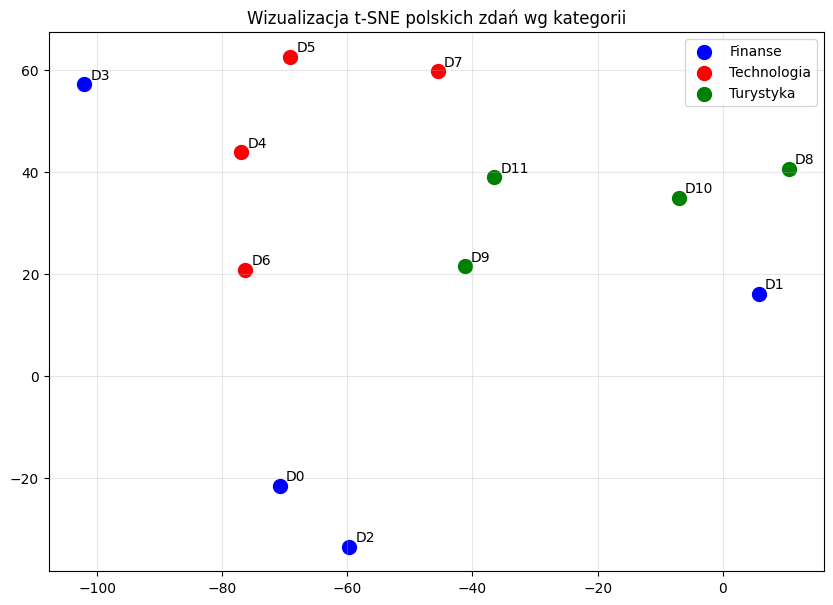

In [38]:
from sklearn.manifold import TSNE

# Wektory zdań już mamy w 'vektor_zdan'
tsne_zdan = TSNE(n_components=2, random_state=42, perplexity=5)
coords_zdan = tsne_zdan.fit_transform(vektor_zdan)

fig, ax = plt.subplots(figsize=(10, 7))
kolory = {"Finanse": "blue", "Technologia": "red", "Turystyka": "green"}

for i, kat in enumerate(kategorie_zdan):
    ax.scatter(coords_zdan[i, 0], coords_zdan[i, 1], c=kolory[kat], s=100,
               label=kat if i % 4 == 0 else "")
    ax.annotate(f"D{i}", (coords_zdan[i, 0]+1, coords_zdan[i, 1]+1))

ax.legend()
ax.set_title("Wizualizacja t-SNE polskich zdań wg kategorii")
plt.grid(True, alpha=0.3)
plt.show()

---
---
## 4. Zadanie do samodzielnej realizacji -- C

### Trenowanie Word2Vec na wiekszym korpusie i porownanie modeli

Pobierz fragment polskiej Wikipedii z Hugging Face i wytrenuj wlasne modele Word2Vec.

**Wykonaj ponizsze kroki:**

1. Pobierz **1000 artykulow** z polskiej Wikipedii (`wikimedia/wikipedia`, `20231101.pl`). Przygotuj zdania za pomoca `simple_preprocess`.
2. Wytrenuj model **Skip-gram** (`sg=1`, `vector_size=100`, `window=5`, `min_count=5`, `epochs=10`).
3. Wytrenuj model **CBOW** (`sg=0`) z tymi samymi parametrami.
4. **Porownaj oba modele** -- dla slow `"polska"`, `"warszawa"`, `"nauka"` wyswietl 5 najblizszych sasiadow z kazdego modelu.
5. Sprawdz **analogie** w wytrenowanym modelu: `polska - warszawa + berlin = ?`, `krol - mezczyzna + kobieta = ?`.
6. **Zapisz** model Skip-gram do pliku i wczytaj go ponownie. Sprawdz, czy wyniki sa identyczne.
7. Zbadaj wplyw parametru `window` -- wytrenuj 3 modele z `window=2`, `window=5`, `window=10` i porownaj wyniki dla slowa `"historia"`.

In [39]:
from datasets import load_dataset

print("Pobieranie danych z Wikipedii (może to chwilę potrwać)...")
ds = load_dataset("wikimedia/wikipedia", "20231101.pl", split="train[:1000]", trust_remote_code=True)

sentences_pl = []
for article in ds:
    text = article["text"]
    for line in text.split("\n"):
        tokens = simple_preprocess(line, deacc=False)
        if len(tokens) >= 3:
            sentences_pl.append(tokens)

print(f"Przygotowano {len(sentences_pl)} zdań do treningu.")
print("Przykładowe zdanie:", sentences_pl[0] if sentences_pl else "Brak")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikimedia/wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikimedia/wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Pobieranie danych z Wikipedii (może to chwilę potrwać)...
Przygotowano 31341 zdań do treningu.
Przykładowe zdanie: ['awk', 'interpretowany', 'język', 'programowania', 'którego', 'główną', 'funkcją', 'jest', 'wyszukiwanie', 'przetwarzanie', 'wzorców', 'plikach', 'lub', 'strumieniach', 'danych', 'jest', 'także', 'nazwą', 'programu', 'początkowo', 'dostępnego', 'dla', 'systemów', 'operacyjnych', 'będących', 'pochodnymi', 'unix', 'obecnie', 'także', 'na', 'inne', 'platformy']


In [40]:
print("Trenowanie modelu Skip-gram...")
model_sg_pl = Word2Vec(
    sentences=sentences_pl,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=10,
    epochs=10,
    workers=4,
    seed=42
)
print("Trening zakończony.")

Trenowanie modelu Skip-gram...
Trening zakończony.


In [26]:
print("Trenowanie modelu CBOW...")
model_cbow_pl = Word2Vec(
    sentences=sentences_pl,
    vector_size=100, window=5, min_count=5,
    sg=0, negative=10, epochs=10, workers=4, seed=42
)
print("Trening CBOW zakończony.")

Trenowanie modelu CBOW...
Trening CBOW zakończony.


In [27]:
slowa_testowe = ["polska", "warszawa", "nauka"]

for word in slowa_testowe:
    print(f"\nSłowo: '{word.upper()}'")
    print(f"  {'Skip-gram':25s} | {'CBOW':25s}")
    print("  " + "-"*55)

    try:
        sim_sg = model_sg_pl.wv.most_similar(word, topn=5)
        sim_cbow = model_cbow_pl.wv.most_similar(word, topn=5)

        for i in range(5):
            w_sg, s_sg = sim_sg[i]
            w_cbow, s_cbow = sim_cbow[i]
            print(f"  {w_sg:15s} ({s_sg:.3f}) | {w_cbow:15s} ({s_cbow:.3f})")
    except KeyError:
        print(f"  Słowo '{word}' nie występuje w słowniku.")


Słowo: 'POLSKA'
  Skip-gram                 | CBOW                     
  -------------------------------------------------------
  rzeczpospolita  (0.707) | ewa             (0.832)
  ludowa          (0.696) | ludowa          (0.827)
  ewa             (0.696) | rzeczpospolita  (0.826)
  gospodarcza     (0.686) | wrocław         (0.819)
  grafika         (0.675) | nowa            (0.815)

Słowo: 'WARSZAWA'
  Skip-gram                 | CBOW                     
  -------------------------------------------------------
  wydawnictwo     (0.842) | wydawnictwo     (0.967)
  pwn             (0.781) | kraków          (0.953)
  red             (0.776) | wyd             (0.950)
  leksykon        (0.762) | red             (0.927)
  kraków          (0.751) | wydanie         (0.914)

Słowo: 'NAUKA'
  Skip-gram                 | CBOW                     
  -------------------------------------------------------
  filozoficzna    (0.807) | obecna          (0.859)
  logos           (0.788) | biblia

In [28]:
def test_analogy(pos, neg):
    try:
        res = model_sg_pl.wv.most_similar(positive=pos, negative=neg, topn=1)
        print(f"{' + '.join(pos)} - {' - '.join(neg)} = {res[0][0]} ({res[0][1]:.4f})")
    except Exception as e:
        print(f"Błąd analogii: {e}")

print("Analogie w modelu Skip-gram:")
test_analogy(["polska", "berlin"], ["warszawa"])
test_analogy(["krol", "kobieta"], ["mezczyzna"]) # Uwaga: wymaga 'krol' w słowniku

Analogie w modelu Skip-gram:
polska + berlin - warszawa = andory (0.6089)
Błąd analogii: "Key 'krol' not present in vocabulary"


In [29]:
# Zapis
model_sg_pl.save("word2vec_pl_sg.model")
print("Model zapisany.")

# Wczytanie
model_loaded = Word2Vec.load("word2vec_pl_sg.model")
print("Model wczytany.")

# Sprawdzenie identyczności
word = "polska"
original_vec = model_sg_pl.wv[word]
loaded_vec = model_loaded.wv[word]
print(f"Wektory są identyczne: {np.allclose(original_vec, loaded_vec)}")

Model zapisany.
Model wczytany.
Wektory są identyczne: True


In [41]:
windows = [2, 5, 10]
wyniki_window = {}

for w in windows:
    print(f"Trenowanie modelu z window={w}...")
    m = Word2Vec(sentences=sentences_pl, vector_size=100, window=w, min_count=5, sg=1, epochs=5, seed=42)
    wyniki_window[w] = m.wv.most_similar("historia", topn=5)

print("\nPorównanie sasiadów słowa 'historia' dla różnych wielkości okna:")
for w in windows:
    neighbors = [n[0] for n in wyniki_window[w]]
    print(f"window={w:2d}: {', '.join(neighbors)}")

Trenowanie modelu z window=2...
Trenowanie modelu z window=5...
Trenowanie modelu z window=10...

Porównanie sasiadów słowa 'historia' dla różnych wielkości okna:
window= 2: instytutu, lublin, francja, minister, piłkarz
window= 5: powszechna, słownik, wstęp, kronika, księga
window=10: średniowiecznej, wstęp, powszechna, kronika, księga
